In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import cartopy.crs as ccrs
from matplotlib.lines import Line2D

import pyodc as odc

import matplotlib.ticker as ticker
import datetime
from matplotlib.dates import drange, MonthLocator, DateFormatter
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib

################################
# If you want to run this on your own, check these paths!!!
p_values = np.loadtxt('data/HadISD_p_vals_a0h3_2000.txt')
station_data = np.loadtxt('data/station_list_167_183_17_1990-2023_thinned.txt', skiprows=1)
sim_infile='data/simulated_synop_data_2000_366.odb'
quant_file = 'data/quantiles_167_152000.odb'

In [2]:
# On LUMI
# p_values = np.loadtxt('../test_output_files/HadISD_p_vals_a0h3_2000.txt')
# station_data = np.loadtxt('/projappl/project_465000454/data/OBSALL/SYNOP/input/STATDATASYNOP/HadISD/station_lists/station_list_167_183_17_1990-2023_thinned.txt', skiprows=1)

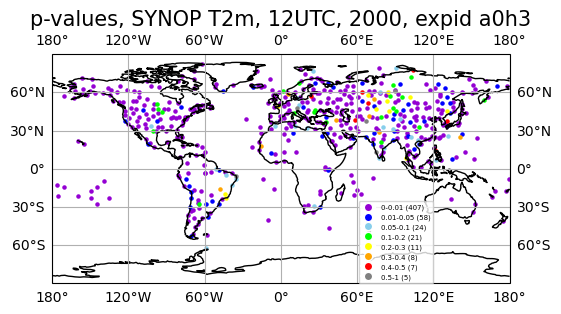

In [4]:
lon_min=-180
lon_max=180
lat_min=-90
lat_max=90

colors = ['darkviolet', 'blue', 'skyblue', 'lime', 'yellow', 'orange', 'red', 'grey']
limits = [0,0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5,1]
    
fig = plt.figure(figsize=(5.5,3), layout='constrained')
#fig_title='P-values for SYNOP rank histograms against observed climate: Experiment ' + experiment + ', Variable ' + variable + ', Year ' + timestring
#fig.suptitle(fig_title, fontsize=15)
    
ax1 = fig.add_subplot(projection=ccrs.PlateCarree())
ax1.set_title('p-values, SYNOP T2m, 12UTC, 2000, expid a0h3', fontsize=15)
ax1.coastlines()
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax1.gridlines(draw_labels=True)
legend_elements = []    
p_freq = [0] * 8
p_mod = 0.5+0.9999*(p_values[:,2]-0.5)
for i in range(len(p_values[:,2])):
    for n in range(8):
        if (p_mod[i] > limits[n]) and (p_mod[i] <= limits[n+1]):
            p_freq[n] = p_freq[n] + 1
    
for n in range(8):
    p_ind = ((p_values[:,2] >= limits[n]) & (p_values[:,2] < limits[n+1]))        
    ax1.scatter(station_data[:,1][p_ind], station_data[:,2][p_ind], s=5, c=colors[n])
    legend_elements.append(Line2D([0], [0], marker='o', color='w',markerfacecolor=colors[n], label=str(limits[n])+'-'+str(limits[n+1])+' ('+str(p_freq[n])+')'))        

    ax1.legend(handles=legend_elements, loc=(0.9, 0.0), bbox_to_anchor=(0.67, 0.0),fontsize=5)

plt.savefig('./obsall_plot_p3.pdf')
plt.show()

In [5]:
# Append the other figure parts here:
# Panel 2 of the plot.

In [6]:
# sim_infile='/projappl/project_465000454/data/OBSALL/SYNOP/output/ODB_data/a0h3/simulated_synop_data_2000_366.odb'
sim = odc.read_odb(sim_infile, single = True, columns = ['year@hdr', 'month@hdr', 'day@hdr', 'hour@hdr', 'longitude@hdr', 'latitude@hdr', 'variable@hdr',  'station@hdr', 'value@body'])

In [7]:
station_id = '152000'
sim['station@hdr'] = sim['station@hdr'].str.strip()
station_data = sim[sim['station@hdr'] == station_id]

In [8]:
utc12 = station_data[station_data['hour@hdr'] == 12]
utc12 = (utc12[["year@hdr","month@hdr","day@hdr","hour@hdr","value@body","variable@hdr","station@hdr"]]).groupby(["year@hdr","month@hdr","day@hdr","hour@hdr","variable@hdr","station@hdr"]).mean() - 273.15

In [9]:
# quant_file = '/projappl/project_465000454/data/OBSALL/SYNOP/input/STATDATASYNOP/HadISD/var167/quantiles/quantiles_167_152000.odb'
quantile_columns = [f'q{str(i).zfill(2)}@body' for i in range(1, 100)]
fixed_columns = ['station@hdr', 'longitude@hdr', 'latitude@hdr', 'elevation@hdr', 'year@hdr', 'month@hdr', 'day@hdr', 'hour@hdr', 'variable@hdr']
all_columns = fixed_columns + quantile_columns
quant_all = odc.read_odb(quant_file, single=True, columns=all_columns)
station_id = '152000'
year = 2000
quant_all['station@hdr'] = quant_all['station@hdr'].astype(str).str.strip()
quant_station = quant_all[quant_all['station@hdr'] == station_id]
quant_station_year = quant_station[quant_station['year@hdr'] == year]
#quant_station_year_00 = quant_station_year[quant_station_year['hour@hdr'] == 0]
#quant_station_year_06 = quant_station_year[quant_station_year['hour@hdr'] == 6]
quant_station_year_12 = quant_station_year[quant_station_year['hour@hdr'] == 12]
#quant_station_year_18 = quant_station_year[quant_station_year['hour@hdr'] == 18]

In [10]:
rank_counts_12 = np.zeros(100)
for i, temp in enumerate(utc12["value@body"]):
    ranks = np.searchsorted(quant_station_year_12[quantile_columns].iloc[i,:], temp, side='right')
    rank_counts_12[ranks] += 1

In [12]:
flat_histogram = np.ones(100)
msd_12 = np.mean((rank_counts_12/3.66 - flat_histogram) ** 2)

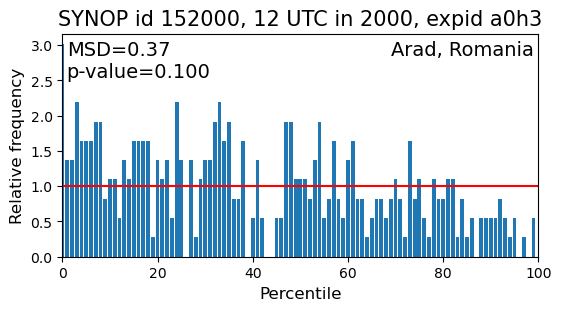

In [13]:
fig = plt.figure(figsize=(5.5,3), layout='constrained')
ax3 = fig.add_subplot()
ax3.set_title('SYNOP id 152000, 12 UTC in 2000, expid a0h3', fontsize=15)
#ax3.set_title(f"12 UTC\nMSD: {msd_12:.2f}, p-value: {p_val_12:.3f}")
ax3.bar(np.arange(100), rank_counts_12/3.65)
ax3.set_xlim(0,100)
ax3.set_xlabel('Percentile', fontsize=12)
ax3.set_ylabel('Relative frequency', fontsize=12)
ax3.axhline(y=1,color='r')
plt.annotate('MSD=0.37', xy=[0.9, 2.85], fontsize=14)
plt.annotate('p-value=0.100', xy=[0.9, 2.55], fontsize=14)
plt.annotate('Arad, Romania', xy=[69.0, 2.85], fontsize=14)
plt.savefig('./obsall_plot_p2.pdf')
plt.show()

In [14]:
# Panel 1 of the plot.

In [15]:
q01 = quant_station_year[['hour@hdr','q01@body']]
q10 = quant_station_year[['hour@hdr','q10@body']]
q25 = quant_station_year[['hour@hdr','q25@body']]
q50 = quant_station_year[['hour@hdr','q50@body']]
q75 = quant_station_year[['hour@hdr','q75@body']]
q90 = quant_station_year[['hour@hdr','q90@body']]
q99 = quant_station_year[['hour@hdr','q99@body']]

days = np.arange(1,366)
day1 = datetime.date(year, 1, 1)
day2 = datetime.date(year+1, 1, 1)
delta = datetime.timedelta(days=1)
dates = drange(day1, day2, delta)
months = np.arange(13)

alpha = [0.5, 0.3, 0.1]
color = 'blue'
scatter_size=5 # size for scattered dots
fs3 = 12 # fontsize for
fs4=10 # fontsize for extra text box, legend
linecolor='red' # color for solid line

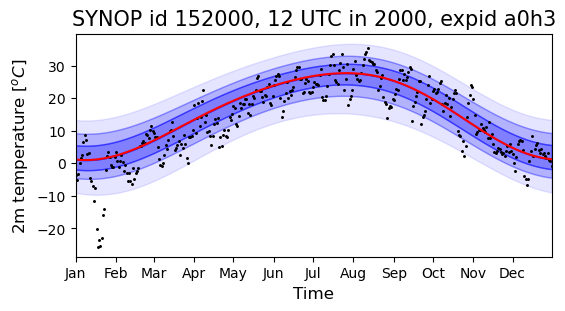

In [25]:
fig = plt.figure(figsize=(5.5,3), layout='constrained')
ax3 = fig.add_subplot()
#ax3.set_title('12 UTC')
ax3.set_title('SYNOP id 152000, 12 UTC in 2000, expid a0h3', fontsize=15)
ax3.fill_between(dates, q25[q25["hour@hdr"]==12].iloc[:,1], q50[q50["hour@hdr"]==12].iloc[:,1], color=color, alpha=alpha[0])
ax3.fill_between(dates, q50[q50["hour@hdr"]==12].iloc[:,1], q75[q75["hour@hdr"]==12].iloc[:,1], color=color, alpha=alpha[0])
ax3.fill_between(dates, q10[q10["hour@hdr"]==12].iloc[:,1], q25[q25["hour@hdr"]==12].iloc[:,1], color=color, alpha=alpha[1])
ax3.fill_between(dates, q75[q75["hour@hdr"]==12].iloc[:,1], q90[q90["hour@hdr"]==12].iloc[:,1], color=color, alpha=alpha[1])
ax3.fill_between(dates, q01[q01["hour@hdr"]==12].iloc[:,1], q10[q10["hour@hdr"]==12].iloc[:,1], color=color, alpha=alpha[2])
ax3.fill_between(dates, q90[q90["hour@hdr"]==12].iloc[:,1], q99[q99["hour@hdr"]==12].iloc[:,1], color=color, alpha=alpha[2]) 
ax3.plot(dates, q50[q50["hour@hdr"]==12].iloc[:,1], 'r-')
ax3.scatter(dates, utc12["value@body"], s=scatter_size, c='k', marker='.')
ax3.set_xlim(dates[0], dates[-1])
ax3.xaxis.set_major_locator(MonthLocator(months))
ax3.xaxis.set_major_formatter(DateFormatter('%b'))
ax3.set_xlabel('Time', fontsize=12)
ax3.set_ylabel('2m temperature $[^oC]$', fontsize=12)
plt.annotate('Arad, Romania', xy=[0.9, 2.85], fontsize=14)
plt.savefig('./obsall_plot_p1.png', format="png", dpi=3600)
plt.show()